In [1]:
# ============================================================
# ライブラリの import
# ============================================================
import torch
import torch.nn as nn          # 層の定義（Linear, ReLU など）
import torch.optim as optim    # 最適化（Adam など）
from torch.utils.data import random_split

from torch.utils.data import DataLoader          # ミニバッチでデータを流す
# from torchvision import datasets, transforms     # MNIST と前処理

#  FashionMNIST は モジュールではなくクラス
# "from torchvision.datasets.FashionMNIST import datasets,transforms

# いったんこっちを採用
from torchvision import datasets, transforms
# 使うとき: datasets.FashionMNIST(...)

# from torchvision.datasets import FashionMNIST
# from torchvision import transforms
# 使うとき: FashionMNIST(...)

In [2]:
# ============================================================
# デバイス選択（GPU があれば cuda、なければ cpu）
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
# 今の環境は CPU でも MNIST MLP なら数分で学習できる

device: cuda


In [3]:
import random

import numpy as np
import torch


SEED = 0


def set_seed(seed: int) -> None:
    """実験の再現性を高めるため、各種乱数を固定する。"""

    # Python標準ライブラリ
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch：CPUとCUDAの乱数を固定
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # CUDAで可能な限り決定論的な処理を使用する
    torch.use_deterministic_algorithms(True)

    # cuDNNのアルゴリズム探索による揺れを防ぐ
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


set_seed(SEED)

In [ ]:
# ============================================================
# 保存先
# ============================================================
import sys
from pathlib import Path

# Notebook の配置が深くなっても src/ を見つけられるよう、
# プロジェクトルート候補を上へたどって import path を補う。
for _candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    _src = _candidate / "src"
    if (_src / "nn_compression").is_dir():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

# 保存先の組み立ては Notebook 内へ重複実装せず、src の共通処理を使う。
from nn_compression.utils import find_project_root, get_experiment_dirs

# method-first のディレクトリ構成に合わせて実験を識別する。
METHOD_NAME = "10_svd"
CASE_NAME = "20_fashion_mnist_mlp"
EXPERIMENT_NAME = "02_mlp_svd_rank_selection"

project_root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    project_root,
    METHOD_NAME,
    CASE_NAME,
    EXPERIMENT_NAME,
)

print(f"project_root: {project_root}")
print(f"data_dir:     {data_dir}")
print(f"models_dir:   {models_dir}")
print(f"results_dir:  {results_dir}")


In [5]:
# ============================================================
# FashionMNIST データの準備
# ============================================================

torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

# ToTensor(): 画像を [0,1] の float テンソルに変換
#   元: PIL Image (28×28) → 後: Tensor (1, 28, 28)
transform = transforms.Compose([
    transforms.ToTensor()
])

# root=data_dir にダウンロード＆キャッシュされる
train_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=transform
)

train_dataset, validation_dataset,validation_dataset_rank = random_split(
    train_dataset,
    [50_000, 5_000, 5_000],
    generator=torch.Generator().manual_seed(0),
)

test_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=transform
)

# DataLoader: データをミニバッチに分割して渡す
validation_loader = DataLoader(
    validation_dataset,
    batch_size=64,   # 1回の更新で使う枚数
    shuffle=False    # 評価用データを並べ替える必要はない。
)

# DataLoader: データをミニバッチに分割して渡す
validation_loader_rank= DataLoader(
    validation_dataset_rank,
    batch_size=64,   # 1回の更新で使う枚数
    shuffle=False    # 評価用データを並べ替える必要はない。
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False    # 評価時は混ぜなくてよい
)

# DataLoader: データをミニバッチに分割して渡す
train_loader = DataLoader(
    train_dataset,
    batch_size=64,   # 1回の更新で使う枚数
    shuffle=True     # 学習時は順番を混ぜる
)

print("train size:", len(train_dataset))  # 55000（分けた）
print("validation size:", len(validation_dataset))  # 5000（分けた）
print("test size:", len(test_dataset))    # 10000（規定値）

train size: 50000
validation size: 5000
test size: 10000


In [6]:
# ============================================================
# MLP の定義（圧縮前のベースライン構造）
# ============================================================
# 784 → 512 → 256 → 10
# あとで fc1 / fc2 の重みを SVD で圧縮する想定
class MNISTMLP(nn.Module):
    # 
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 512)  # ここが圧縮の主な対象候補
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(256, 10)   # 出力は 10 クラス（数字 0〜9）

    def forward(self, x):
        # x shape: (batch_size, 1, 28, 28)

        #-1→ 残りの次元を自動で計算する。
        # if self.training:
        # ...
        # else:
        # ...
        # 画像を1次元ベクトルに変換（MLP はベクトル入力）
        # x.size(0)→ バッチサイズ(64)をそのまま残す。
        x = x.view(x.size(0), -1)  # (batch_size, 784)

        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)  # logits（ソフトマックス前の生スコア）を返す

        return x

In [7]:
# ============================================================
# モデル・損失関数・最適化手法の準備
# ============================================================

# MNISTMLP() で、さっき定義したニューラルネット本体を作っています。
# .to(device) は、そのモデルをGPU に移しています。
model = MNISTMLP().to(device)

# 多クラス分類なので CrossEntropyLoss
# （内部で log_softmax + NLLLoss をやるので、モデル出力は logits のまま）
criterion = nn.CrossEntropyLoss()

# Adam: 学習率 0.001 はよく使う初期値
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

MNISTMLP(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


In [8]:
# ============================================================
# 学習 1 epoch = 「全データを1回見て、間違いを直す」
# ============================================================
# 1バッチごとのやること（これが学習の本体）:
#   1. 画像を入れる → 予測が出る
#   2. 正解と比べて loss（間違い）を計算
#   3. 「どの重みをどう直せばいいか」を計算（backward）
#   4. 重みを少し更新（step）
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    # model.train() は nn.Module が持っている仕組み
    # モデル自身とその子モジュールの training 状態を True にします
    # 今はなくてもあっても変わらない
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:  # 64枚ずつ取り出す
        images = images.to(device)
        labels = labels.to(device)

        # PyTorch は勾配を足し込むので、毎回リセット
        optimizer.zero_grad()            # ① 前回の修正メモを消す

        # forwardを使って計算している
        # outputs = model.forward(images)と同じ
        outputs = model(images)          # ② 予測（10クラス分のスコア）

        loss = criterion(outputs, labels)  # ③ 間違いの大きさ

        # 誤差逆伝播をして勾配を作る
        # forwardで計算したlossをbackwardで勾配を計算する
        loss.backward()                  # ④ どこを直せばいいか計算

        # backwardで計算した勾配をstepで更新する
        optimizer.step()                 # ⑤ 重みを少し直す

        # loss.item() はそのバッチの平均損失
        # images.size(0) を掛けるのは、64枚分の損失の合計っぽいものに直して、
        # あとで全体平均を取るため
        total_loss += loss.item() * images.size(0)

        # 0~9での各スコアを比較して１番大きいものをとる→これが予測
        predicted = torch.argmax(outputs, dim=1)  # 一番高いスコアの数字

        # 予測と正解を比較して、正解している数を数える
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total   # 平均 loss
    accuracy = correct / total      # 正解率

    return avg_loss, accuracy

In [9]:
# ============================================================
# テストデータでの評価（学習はしない）
# ============================================================
def evaluate(model, loader, criterion, device):
    model.eval()  # 評価モード

    total_loss = 0.0
    correct = 0
    total = 0

    # 評価時は勾配不要 → メモリ節約・高速化
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # 画像をモデルへ入力して、各クラスのスコアを取得します。
            #tensor([-1.2,0.3,2.7,-0.8,1.1,-2.0,0.4,-1.5,0.2,-0.7,])
            # logitと呼ばれる未正規化スコアです。
            outputs = model(images)
            # 交差エントロピーloss、これは平均値で出る
            loss = criterion(outputs, labels)
            # 平均値で出るので、バッチ内の件数を掛けて、バッチ全体のloss合計
            total_loss += loss.item() * images.size(0)

            #outputsは各画像について10クラス分のスコアを持っています。
            #dim=1は、クラス方向に最大値を探すという意味です。
            predicted = torch.argmax(outputs, dim=1)
            # 予測と正解を比較して、正解している数を数える
            correct += (predicted == labels).sum().item()
            #
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [10]:
import copy

MAX_EPOCHS = 50
PATIENCE = 5
MIN_DELTA = 1e-4

best_validation_loss = float("inf")
best_epoch = None
best_model_state = None
no_improvement_count = 0
results = []
for epoch in range(MAX_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
    )

    validation_loss, validation_acc = evaluate(
        model,
        validation_loader,
        criterion,
        device,
    )


    # epoch終了後の同じモデルでTrainを再評価
    train_eval_loss, train_eval_acc = evaluate(
        model,
        train_loader,
        criterion,
        device,
    )


    # バリデーションデータの損失が改善したかどうかを確認
    if best_validation_loss - MIN_DELTA > validation_loss:
        # バリデーションデータの損失が改善した場合
        best_validation_loss = validation_loss 
        best_epoch = epoch+1
        # モデルの重みやバイアスなど、学習済みパラメータの辞書
        # copyはmodel.state_dict()が変わっても大丈夫なように
        best_model_state = copy.deepcopy(model.state_dict())
        no_improvement_count = 0
    else:
        # バリデーションデータの損失が改善しなかった場合
        no_improvement_count += 1

    row = {
        "epoch": epoch+1,
        "train_acc":train_eval_acc,
        "train_loss": train_eval_loss,
        "validation_loss": validation_loss,
        "validation_acc": validation_acc,
    }
    results.append(row)

    # バリデーションデータの損失が規定回数改善しなかった場合
    if no_improvement_count >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break
    

# best_model_stateをmodelへ読み込む 
model.load_state_dict(best_model_state)
baseline_state = copy.deepcopy(model.state_dict())
# 最良重みに戻した後でTestデータを評価する
#test_loss, test_acc = evaluate(
#    model,
#    test_loader,
#    criterion,
#    device,
#)
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_validation_loss:.4f}")
#rint(f"Test loss: {test_loss:.4f}")
#print(f"Test accuracy: {test_acc:.4f}")


Early stopping at epoch 17
Best epoch: 12
Best validation loss: 0.2997


In [11]:
# ============================================================
# SVD（学習の外で、重み行列 W を分解する）
# ============================================================
# W ≈ U_r @ diag(S_r) @ Vh_r
#   U_r : 左特異ベクトル（out × r）
#   S_r : 特異値（r,）← 対角行列の対角成分だけ
#   Vh_r: 右特異ベクトル（r × in）
def SVD(W, r):
    """重み行列 W を rank r で打ち切った SVD を返す"""
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    U_r = U[:, :r]   # 上位 r 列だけ残す
    S_r = S[:r]      # 上位 r 個の特異値
    Vh_r = Vh[:r, :] # 上位 r 行だけ残す

    return U_r, S_r, Vh_r

In [12]:
# ============================================================
# 1層を2層に分けて計算コストを削減する
# ============================================================
# 元: Linear(in → out)
# 後: Linear(in → r, bias=False) + Linear(r → out, bias=True)
#
# 対応:
#   first.weight  = Vh_r
#   second.weight = U_r @ diag(S_r)
#   second.bias   = 元の bias
def devidetwolayer(layer,r):
    # 中間次元と低ランク数はいっしょにすべき？
    # → ここでは中間次元 = rank r として分解している
    U_r, S_r, Vh_r = SVD(layer.weight.detach(),r)  # detach: 勾配グラフから外す
    first_layer = nn.Linear(layer.in_features, r, bias=False)  # 中間次元 r、bias は不要
    second_layer = nn.Linear(r, layer.out_features, bias=True)  # 最終出力、bias はここに置く
    with torch.no_grad():  # 重みの代入時は勾配を計算しない
        first_layer.weight.copy_(Vh_r)                  # (r, in)
        second_layer.weight.copy_(U_r @ torch.diag(S_r))  # (out, r)
        second_layer.bias.copy_ (layer.bias.data)      # 元の bias をそのまま
    # 新規 Linear は CPU 上で作られるので、元の層と同じ device へ移す
    # 元の layer.weight がいる device を見て、新しく作った first_layer と second_layer を
    # 同じ場所に移してから返す、
    return nn.Sequential(first_layer,second_layer).to(layer.weight.device)


In [13]:
# ============================================================
# 2層に分解しせず、SVDを適用したモデルで評価
# ============================================================
# one_layer_svd_mode の骨格だけ作り、各 fc を「学習済み model の圧縮版」で差し替える
# 今は使ってない

def make_one_layer_svd_model(model,r1,r2):
    one_layer_svd_model = MNISTMLP().to(device)
    # *は関数の結果を分解して渡す
    one_layer_svd_model.fc1 = RebuildSVD(*SVD(model.fc1.weight.detach(),r1),model.fc1)
    # fc2: 512→256
    one_layer_svd_model.fc2 = RebuildSVD(*SVD(model.fc2.weight.detach(),r2),model.fc2)
    # fc3: 256→10（もともと小さい層）
    #one_layer_svd_mode.fc3 = RebuildSVD(*SVD(model.fc3.weight.detach(),r3),model.fc3)
    one_layer_svd_model.fc3 =model.fc3

    return one_layer_svd_model

In [14]:
# ============================================================
# 2層に分解し、SVDを適用したモデルで評価
# ============================================================
# two_layer_svd_model の骨格だけ作り、各 fc を「学習済み model の圧縮版」で差し替える

def make_two_layer_svd_model(model,r1,r2):
    two_layer_svd_model = MNISTMLP().to(device)
    # modelに近似したものを入れる（rank が小さいほど圧縮↑）
    two_layer_svd_model.fc1 = devidetwolayer(model.fc1,r1)
    two_layer_svd_model.fc2 = devidetwolayer(model.fc2,r2)
    #two_layer_svd_model.fc3 = devidetwolayer(model.fc3,r3)
    two_layer_svd_model.fc3 = model.fc3

    return two_layer_svd_model

In [15]:
# ============================================================
# MACs(Multiply-Accumulate Operations（乗算加算演算)
# ============================================================
# 1サンプルあたりの計算量の理論値
# Linear(in→out) ≈ in * out
# 圧縮後2層 ≈ in*r + r*out
def linear_macs(layer):
    #Linear層の1サンプル当たりのMACs
    return layer.in_features * layer.out_features

def compressed_linear_macs(in_features, out_features, rank):
    #SVD後の2層LinearのMACs
    return in_features * rank + rank * out_features

def MACs(model, r1, r2, verbose=True):
    baseline_macs = (
        linear_macs(model.fc1)
        + linear_macs(model.fc2)
        + linear_macs(model.fc3)
    )

    compressed_macs = (
        compressed_linear_macs(784, 512, r1)
        + compressed_linear_macs(512, 256, r2)
        + linear_macs(model.fc3)
    )

    # 計算量が何割減ったか
    compute_reduction_rate = 1.0 - compressed_macs / baseline_macs

    if verbose:
        print("Baseline MACs:", baseline_macs)
        print("Compressed MACs:", compressed_macs)
        print(f"Compute reduction: {compute_reduction_rate:.2%}")

    # グラフ用には compressed_macs を主に使う
    return baseline_macs, compressed_macs, compute_reduction_rate


In [16]:
# ============================================================
# 精度の低下量（圧縮のトレードオフ）
# ============================================================
# test_acc     : 圧縮前（学習直後）
# new_test_acc : 圧縮後

def accuracy_drop(test_acc, new_test_acc, verbose=True):
    drop = test_acc - new_test_acc
    if verbose:
        print("Baseline accuracy:", test_acc)
        print("Compressed accuracy:", new_test_acc)
        # drop は float なので、Python 標準の round を使う
        # （torch.round は Tensor 用）
        print("Accuracy drop:", round(drop, 5))
    return drop  # results やグラフ用に数値を返す

In [17]:
# ============================================================
# 実測の推論速度比較（1バッチあたりの平均時間）
# ============================================================
import time

def benchmark_inference(model,data_loader, device, warmup=10, repeats=5000):
    """1バッチ当たりの平均推論時間を測定する。"""
    # このコードでは意味ない
    # → 小さな MLP + GPU だと差が出にくい、という意味合い
    model.eval()

    images, _ = next(iter(data_loader))
    images = images.to(device)

    # ウォームアップ（初回の遅さを測りに入れない）
    # _は捨て変数で使わないの意味
    # 何回かウォームアップするけど、値は使わないよってこと
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(images)

    # GPU は非同期なので、計時前後で同期して正確に測る
    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.no_grad():
        for _ in range(repeats):
            _ = model(images)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    return elapsed / repeats  # 1回あたりの秒数

def benchmark_inference_print(model, two_layer_svd_model, test_loader, device, verbose=True):
    baseline_time = benchmark_inference(model, test_loader, device)
    two_layer_svd_model_time = benchmark_inference(two_layer_svd_model, test_loader, device)

    if verbose:
        print(f"Baseline: {baseline_time * 1000:.3f} ms/batch")
        print(f"TwolayerSVD: {two_layer_svd_model_time * 1000:.3f} ms/batch")

    # 秒 → あとで DataFrame では ms にしてもよい
    return baseline_time, two_layer_svd_model_time


In [18]:
# ============================================================
# 予測一致率 agreement
# ============================================================
# 正解ラベルとの一致（accuracy）ではなく、
# 「圧縮前モデルと同じクラスを予測した割合」を測る。
# Acc が同程度でも、別の間違い方をしていないかのチェック用。
def agreement(baseline, compressed, loader, device):
    baseline.eval()
    compressed.eval()

    agreement_count = 0
    total = 0

    # inference_mode: 勾配不要・推論専用（no_grad より少し軽い）
    with torch.inference_mode():
        # ラベルは使わないので _ で捨てる
        for images, _ in loader:
            images = images.to(device)

            # 各サンプルの予測クラス（スコア最大の次元）
            baseline_pred = baseline(images).argmax(dim=1)
            compressed_pred = compressed(images).argmax(dim=1)

            agreement_count += (
                baseline_pred == compressed_pred
            ).sum().item()
            total += images.size(0)

    return agreement_count / total  # 0〜1（1 = 完全に同じ予測）


In [19]:
# ============================================================
# logits の RMSE（出力スコアのずれ）
# ============================================================
# agreement は「最終予測クラス」だけ見るのに対し、
# こちらは 10 クラス分の生スコア（logits）全体のずれを測る。
# 予測クラスが同じでも、確信度の差が大きいと RMSE は上がる。
def logits_rmse(baseline, compressed, loader, device):
    baseline.eval()
    compressed.eval()

    squared_error_sum = 0.0
    element_count = 0

    with torch.inference_mode():
        for images, _ in loader:
            images = images.to(device)

            # argmax せず、全クラスの logits を比較する
            baseline_logits = baseline(images)       # (batch, 10)
            compressed_logits = compressed(images)   # (batch, 10)

            difference = baseline_logits - compressed_logits
            squared_error_sum += difference.square().sum().item()
            element_count += difference.numel()

    # √(平均二乗誤差) → 要素あたりの典型的なズレ
    return (squared_error_sum / element_count) ** 0.5


In [20]:
# ============================================================
# 特異値エネルギーの保持率 retained_energy
# ============================================================
# Frobenius ノルムの二乗 = 特異値の二乗和、なので
#   sum(S[:r]^2) / sum(S^2)
# は「rank r で重みのエネルギーの何割を残したか」になる。
# 1 に近いほど近似が良く、精度低下も抑えやすい目安。
def retained_energy(layer, rank):
    singular_values = torch.linalg.svdvals(
        layer.weight.detach()
    )

    return (
        singular_values[:rank].square().sum()
        / singular_values.square().sum()
    ).item()


In [21]:
# ============================================================
# パラメータ数を数える（圧縮後と比較する基準）
# ============================================================
# fc1: 784*512+512 = 401,920
# fc2: 512*256+256 = 131,328
# fc3: 256*10+10   =   2,570
# 合計             = 535,818
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

baseline_params = count_parameters(model)
print("Baseline params:", baseline_params)

def parameters_reduction(model,two_layer_svd_model):
    return 1.0 - count_parameters(two_layer_svd_model) / count_parameters(model)


Baseline params: 535818


In [22]:
# ============================================================
# rank を変えて精度・params・MACs・近さ指標を集める
# ============================================================
import itertools

r1_list = [16, 32, 64, 128,256,512]  # fc1 の候補
r2_list = [16, 32, 64, 128,256]  # fc2 の候補
rank_configs = list(itertools.product(r1_list, r2_list))

# ベースライン推論時間は1回だけ測る（ループ内で毎回やらない）
baseline_time_s = benchmark_inference(
    model, test_loader, device, warmup=20, repeats=2000
)

baseline_rank_validation_loss, baseline_rank_validation_acc = evaluate(
    model,
    validation_loader_rank,
    criterion,
    device,
)
results = []

for fc1_rank, fc2_rank in rank_configs:
    two_layer_svd_model = make_two_layer_svd_model(
        model,
        r1=fc1_rank,
        r2=fc2_rank,
    )

    two_layer_validation_loss, two_layer_validation_accuracy = evaluate(
        two_layer_svd_model,
        validation_loader_rank,
        criterion,
        device,
    )

    # verbose=False で print を抑え、戻り値だけ使う
    drop = accuracy_drop(baseline_rank_validation_acc, two_layer_validation_accuracy, verbose=False)
    # _ は「ここに何か来るけど、今回は使わない」という意味の捨て変数
    _, compressed_macs, compute_reduction = MACs(
        model, fc1_rank, fc2_rank, verbose=False
    )
    compressed_time_s = benchmark_inference(
        two_layer_svd_model, validation_loader_rank, device, warmup=5, repeats=200
    )
    retained_energy_fc1 = retained_energy(model.fc1, fc1_rank)
    retained_energy_fc2 = retained_energy(model.fc2, fc2_rank)

    row = {
        "fc1_rank": fc1_rank,
        "fc2_rank": fc2_rank,
        "parameters": count_parameters(two_layer_svd_model),
        "parameters_reduction": parameters_reduction(model,two_layer_svd_model),
        "validation_loss": two_layer_validation_loss,
        "validation_acc": two_layer_validation_accuracy,
        "accuracy_drop": drop,
        "compressed_macs": compressed_macs,
        "compute_reduction": compute_reduction,
        "baseline_time_ms": baseline_time_s * 1000,
        "compressed_time_ms": compressed_time_s * 1000,
        # 近さ指標: 予測一致率 / logits ずれ / 特異値エネルギー保持率
        "agreement": agreement(model, two_layer_svd_model,validation_loader_rank, device),
        "logits_rmse": logits_rmse(model, two_layer_svd_model,validation_loader_rank, device),
        "retained_energy_fc1": retained_energy_fc1,
        "retained_energy_fc2": retained_energy_fc2,
        "model":two_layer_svd_model
    }
    results.append(row)
   
    # 進行状況は1行だけ
    print(
        f"r1={fc1_rank:3d}, r2={fc2_rank:3d} | "
        f"Acc={two_layer_validation_accuracy:.4f} "
        f"loss={two_layer_validation_loss:.4f} "
        f"params_reduction={row['parameters_reduction']:.4f} "
        f"(drop={drop:+.4f}) | "
        f"params={row['parameters']} | "
        f"MACs={compressed_macs}|"
        f"time={compressed_time_s*1000:.3f}ms|"
        f"agreement={row['agreement']:.4f}"
    )

print(f"\n集計完了: {len(results)} 件")


r1= 16, r2= 16 | Acc=0.7780 loss=0.6294 params_reduction=0.9321 (drop=+0.1174) | params=36362 | MACs=35584|time=0.155ms|agreement=0.7928
r1= 16, r2= 32 | Acc=0.7664 loss=0.6686 params_reduction=0.9092 (drop=+0.1290) | params=48650 | MACs=47872|time=0.152ms|agreement=0.7844
r1= 16, r2= 64 | Acc=0.7750 loss=0.6613 params_reduction=0.8633 (drop=+0.1204) | params=73226 | MACs=72448|time=0.150ms|agreement=0.7952
r1= 16, r2=128 | Acc=0.7762 loss=0.6493 params_reduction=0.7716 (drop=+0.1192) | params=122378 | MACs=121600|time=0.201ms|agreement=0.7952
r1= 16, r2=256 | Acc=0.7722 loss=0.6537 params_reduction=0.5881 (drop=+0.1232) | params=220682 | MACs=219904|time=0.167ms|agreement=0.7928
r1= 32, r2= 16 | Acc=0.8668 loss=0.3802 params_reduction=0.8934 (drop=+0.0286) | params=57098 | MACs=56320|time=0.205ms|agreement=0.9126
r1= 32, r2= 32 | Acc=0.8646 loss=0.3767 params_reduction=0.8705 (drop=+0.0308) | params=69386 | MACs=68608|time=0.156ms|agreement=0.9176
r1= 32, r2= 64 | Acc=0.8632 loss=0.37

In [23]:
def GetPoint(df, column,x,y):
    """
    knee 点計算用に、端点の座標ペアを返す。"""
    # column で並べ替え（端点 = 先頭と末尾）
    df_sorted = df.sort_values(column).reset_index(drop=True)
    p = (df_sorted[x].iloc[0], df_sorted[y].iloc[0])    # 始点の座標

    return p


In [24]:
def GetEndPoint(df, column, x, y):
    """
    knee 点計算用に、端点の座標ペアを返す。

    Parameters
    ----------
    df : DataFrame
        Pareto 点など、端点を取りたい表
    column : str
        ソートに使う列名（例: "parameters"）
        この列の最小側・最大側を端点にする
    x, y : str
        座標として取り出す列名（例: "parameters", "validation_loss"）

    Returns
    -------
    p0, p1 : tuple[float, float]
        p0 = (x0, y0) 始点（column が小さい側）
        p1 = (x1, y1) 終点（column が大きい側）
        → GetLinearEquation(p0, p1) にそのまま渡せる
    """
    # column で並べ替え（端点 = 先頭と末尾）
    df_sorted = df.sort_values(column).reset_index(drop=True)

    # 行全体を取り出す（あとで x, y 列だけ抜く）
    left = df_sorted.iloc[0]    # column 最小の行
    right = df_sorted.iloc[-1]  # column 最大の行

    # 行から座標だけ取り出し、(x, y) タプルにする
    # 例: left["parameters"], left["validation_loss"] → (12345, 0.35)
    p0 = (left[x], left[y])    # 始点の座標
    p1 = (right[x], right[y])  # 終点の座標

    return p0, p1


In [25]:
def GetlinearEquation(p0,p1):
    x0,y0=p0
    x1,y1=p1
    slope=(y1-y0)/(x1-x0)
    intercept=y0-x0*slope
    return slope,intercept

In [26]:
# ============================================================
# knee 点: 端点を結ぶ直線から最も遠い点
# 後で .py 化するとき → 例: utils/pareto_knee.py にまとめる想定
# ------------------------------------------------------------
# 同じ役割の実装を2つ残す（名前を分ける。同名だと後勝ちで上書きされる）
#   GetKneePoint_loop  … 学習用・点が少ないとき（依存少）
#   GetKneePoint_numpy … 点がたくさんあるとき向け
# ノート内のデフォルト呼び出しは GetKneePoint (= loop) を使う
# ============================================================

def GetKneePoint_loop(df, slope, intercept, x, y):
    """
    【用途】Pareto 上の knee 点（ループ実装）

    - 読みやすさ・学習用。点数〜数百ならこれで十分
    - 依存: pandas のみ（numpy 不要）
    - 後で .py 化: デフォルト実装として残す想定

    Returns
    -------
    point : tuple
        (x, y) 座標
    best_dist : float
        直線からの距離
    """
    best_dist = -1.0  # 距離は常に >=0 なので、初回必ず更新される
    best_x, best_y = None, None
    denom = (slope**2 + 1) ** 0.5  # 分母は点によらないのでループ外

    for _, row in df.iterrows():
        # 点と直線 y = slope*x + intercept の距離
        dist = abs(slope * row[x] - row[y] + intercept) / denom
        if dist > best_dist:
            best_dist = dist
            best_x, best_y = row[x], row[y]

    return (best_x, best_y), best_dist


# ノート・将来モジュールの「普通に使う方」
#GetKneePoint = GetKneePoint_loop


In [27]:
import numpy as np

def GetKneePoint_numpy(df, slope, intercept, x, y):
    """
    【用途】Pareto 上の knee 点（NumPy ベクトル化実装）

    - GetKneePoint_loop と同じ定義・同じ戻り値
    - 点が数千〜と多いときの高速版候補
    - 依存: numpy
    - 後で .py 化: オプション実装として併置する想定
      （例: prefer="numpy" で切り替える、など）

    Returns
    -------
    point : tuple
        (x, y) 座標
    best_dist : float
        直線からの距離
    """
    xs = df[x].to_numpy(dtype=float)
    ys = df[y].to_numpy(dtype=float)

    # 全点まとめて距離を計算（ベクトル化）
    dist = np.abs(slope * xs - ys + intercept) / np.sqrt(slope**2 + 1)

    knee_idx = int(np.argmax(dist))  # 最大距離の位置
    knee_row = df.iloc[knee_idx]
    return (knee_row[x], knee_row[y]), float(dist[knee_idx])


saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_mlp_svd_rank_selection\parameters_vs_validation_loss_normalize.png
pareto points: 11


,fc1_rank,fc2_rank,parameters,validation_loss,parameters_normalize,validation_loss_normalize
0,16,16,36362,0.629381,0.000000,1.000000
1,32,16,57098,0.380187,0.052224,0.273265
2,32,32,69386,0.376715,0.083172,0.263139
3,64,16,98570,0.304215,0.156673,0.051704
4,64,32,110858,0.300669,0.187621,0.041361
5,64,64,135434,0.297295,0.249516,0.031521
6,64,128,184586,0.297146,0.373308,0.031089
7,128,32,193802,0.291303,0.396518,0.014048
8,128,64,218378,0.288164,0.458414,0.004894
9,128,128,267530,0.287246,0.582205,0.002215


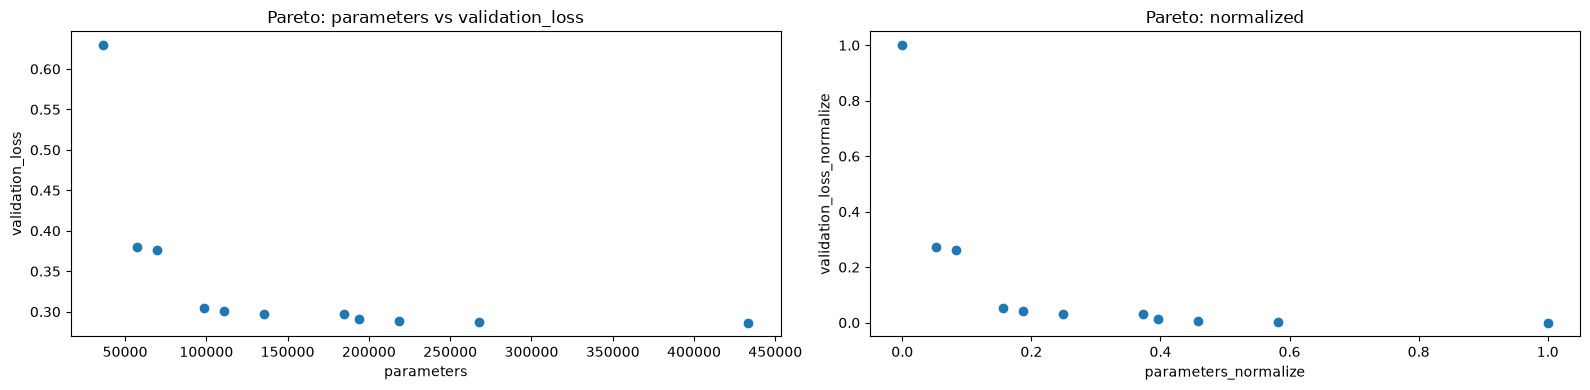

In [28]:
# ============================================================
# Pareto Frontier
# ============================================================
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

baseline_params = count_parameters(model)
df_results_for_pareto = pd.DataFrame(results)

df_pareto_view = df_results_for_pareto.copy()
# ベースラインよりパラメタ数が多いランクペアを落とす
df_pareto_view = df_pareto_view[df_pareto_view["parameters"] <= baseline_params]
# ベースラインより MACs が減っているランクペアだけ残す
df_pareto_view = df_pareto_view[df_pareto_view["compute_reduction"] > 0].copy()

# ------------------------------------------------------------
# 【元コード】うまくいかなかった書き方（学習用に残す）
# ------------------------------------------------------------
# from nt import replace  # 不要。補完などで混入したもの
#
# for index, row in df_pareto_view.iterrows():
#     # NG1: Python の and は Series の真偽を求めようとして
#     #      ValueError: The truth value of a Series is ambiguous
#     # if any(df_pareto_view["parameters"] <= row["parameters"] and
#     #        df_pareto_view["validation_loss"] <= row["validation_loss"]):
#
#     # NG2: and を & に変えても、any(Series) より Series.any() を使うべき
#     #      また括弧が無いと演算子の優先順位で意図と違う式になる
#     # if any((df_pareto_view["parameters"] <= row["parameters"])
#     #        & (df_pareto_view["validation_loss"] <= row["validation_loss"])
#     #        & (index != df_pareto_view.index)):
#
#     # NG3: iterrows 中に inplace drop すると、走査中に表が変わって
#     #      行が飛んだり KeyError になったりしやすい
#     #     df_pareto_view.drop(index=index, inplace=True)
#
#     # NG4: drop(..., replace=True) は誤り。正しくは inplace=True か代入
#     # NG5: 両方 <= だけだと「厳密に良い点」が無くても落ちる/残る判定が曖昧。
#     #      自分自身も両方 <= で True になるので、除外 or 厳密不等号が必要

# ------------------------------------------------------------
# 【修正版】Pareto frontier（parameters↓ かつ validation_loss↓ が良い）
# ある点より「両方とも同等以上、かつ少なくとも一方は厳密に良い」点が
# 1つでもあれば、その点は劣後（dominated）なので落とす
# ・& で要素ごとの AND
# ・.any() で「1つでも True か」
# ・残す index を集めて最後に一度だけ絞る（ループ中 drop しない）
# ------------------------------------------------------------
keep_indices = []
for index, row in df_pareto_view.iterrows():
    # dominated: 「row より良い（または同等で一方は厳密に良い）点」がどこにあるか
    # True の行 = row を優越している点
    dominated = (
        (df_pareto_view["parameters"] <= row["parameters"])
        & (df_pareto_view["validation_loss"] <= row["validation_loss"])
        & (
            (df_pareto_view["parameters"] < row["parameters"])
            | (df_pareto_view["validation_loss"] < row["validation_loss"])
        )
    )
    # この if は必要。
    # dominated を計算しただけでは行は消えない。
    # ・dominated.any() == True  → 誰かに負けている → 捨てる
    # ・dominated.any() == False → 誰にも負けていない → Pareto に残す
    # 自分自身は両方 < にならないので、ここでの True には含まれない
    if not dominated.any():
        keep_indices.append(index)

df_pareto_view = df_pareto_view.loc[keep_indices].copy()
df_pareto_view = df_pareto_view.sort_values("parameters").reset_index(drop=True)

scaler = MinMaxScaler()
df_pareto_view[
    ["parameters_normalize", "validation_loss_normalize"]
] = scaler.fit_transform(
    df_pareto_view[["parameters", "validation_loss"]]
)

# parameters vs validation_loss
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
ax[0].scatter(
    df_pareto_view["parameters"],
    df_pareto_view["validation_loss"],
    marker="o",
)
ax[0].set_xlabel("parameters")
ax[0].set_ylabel("validation_loss")
ax[0].set_title("Pareto: parameters vs validation_loss")

ax[1].scatter(
    df_pareto_view["parameters_normalize"],
    df_pareto_view["validation_loss_normalize"],
    marker="o",
)
ax[1].set_xlabel("parameters_normalize")
ax[1].set_ylabel("validation_loss_normalize")
ax[1].set_title("Pareto: normalized")

plt.tight_layout()
results_dir.mkdir(parents=True, exist_ok=True)
parameters_vs_validation_loss_path = (
    results_dir / "parameters_vs_validation_loss_normalize.png"
)
fig.savefig(parameters_vs_validation_loss_path, dpi=150, bbox_inches="tight")
print("saved:", parameters_vs_validation_loss_path.resolve())
print("pareto points:", len(df_pareto_view))
display(df_pareto_view[
    ["fc1_rank", "fc2_rank", "parameters", "validation_loss",
     "parameters_normalize", "validation_loss_normalize"]
].sort_values("parameters"))
plt.show()


In [29]:
p0 = GetPoint(
    df_pareto_view,
    "parameters_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)
# NG: y 列が "validation_loss"（正規化前）だと、正規化空間の端点にならない
# p1 = GetPoint(
#     df_pareto_view,
#     "validation_loss_normalize",
#     "parameters_normalize",
#     "validation_loss",
# )
p1 = GetPoint(
    df_pareto_view,
    "validation_loss_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)

p, distance = GetKneePoint_loop(
    df_pareto_view,
    *GetlinearEquation(p0, p1),
    "parameters_normalize",
    "validation_loss_normalize",
)
print("distance:", distance)
print(
    "best pair  parameters_normalize:",
    p[0],
    ", validation_loss_normalize:",
    p[1],
)

# parameters 順に並べてから「knee の前後」を取る
df_pareto_view = df_pareto_view.sort_values("parameters").reset_index(drop=True)

# knee 行の位置（0,1,2,...）
knee_mask = (
    (df_pareto_view["parameters_normalize"] == p[0])
    & (df_pareto_view["validation_loss_normalize"] == p[1])
)
knee_pos = int(df_pareto_view.index[knee_mask][0])

# NG（旧）: indices+1 は「ラベル全部に +1」で、隣行の意味にならない
#          loc[len(df)] への代入も壊れやすい
# indices = df_pareto_view.index[knee_mask]
# df_pareto_best = df_pareto_view.loc[knee_mask]
# df_pareto_best.loc[len(df_pareto_best)] = df_pareto_view.loc[indices + 1]
# df_pareto_best.loc[len(df_pareto_best)] = df_pareto_view.loc[indices - 1]

# OK: iloc で前後を含めてスライス（端なら存在する側だけ）
left = max(knee_pos - 1, 0)
right = min(knee_pos + 1, len(df_pareto_view) - 1)

# knee 本体（評価・selected_rank.csv 用）
df_pareto_knee = df_pareto_view.iloc[[knee_pos]].copy()
# knee ±1（parameters 順の前後も見たい用）
df_pareto_best = df_pareto_view.iloc[left : right + 1].copy()

print(f"knee_pos={knee_pos}, neighbors iloc[{left}:{right + 1}] (knee ±1 by parameters)")
print("knee:")
display(df_pareto_knee.drop(columns="model"))
print("knee ±1:")
display(df_pareto_best.drop(columns="model"))



distance: 0.5597619332048335
best pair  parameters_normalize: 0.15667311411992263 , validation_loss_normalize: 0.05170396824161927
knee_pos=3, neighbors iloc[2:5] (knee ±1 by parameters)
knee:


,fc1_rank,fc2_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_fc1,retained_energy_fc2,parameters_normalize,validation_loss_normalize
3,64,16,98570,0.816038,0.304215,0.892,0.0034,97792,0.817225,0.135121,0.162425,0.9556,1.807795,0.837824,0.59551,0.156673,0.051704


knee ±1:


,fc1_rank,fc2_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_fc1,retained_energy_fc2,parameters_normalize,validation_loss_normalize
2,32,32,69386,0.870505,0.376715,0.8646,0.0308,68608,0.871770,0.135121,0.155571,0.9176,2.657922,0.706678,0.717894,0.083172,0.263139
3,64,16,98570,0.816038,0.304215,0.8920,0.0034,97792,0.817225,0.135121,0.162425,0.9556,1.807795,0.837824,0.595510,0.156673,0.051704
4,64,32,110858,0.793105,0.300669,0.8930,0.0024,110080,0.794258,0.135121,0.154388,0.9682,1.173226,0.837824,0.717894,0.187621,0.041361


In [30]:
# ============================================================
# Reference Test Evaluation
# 注意:
# この Test 結果は rank 選択には使用しない。
# rank 選択は Pareto frontier + knee ±1 で完結させる。
# ============================================================

# NG（旧）: df_pareto_best は前後込みなので iloc[0] は knee とは限らない
# best_model = df_pareto_best["model"].iloc[0]
# fc1_rank = df_pareto_best["fc1_rank"].iloc[0]
# fc2_rank = df_pareto_best["fc2_rank"].iloc[0]

# OK: knee 本体は df_pareto_knee を使う
pareto_results = []
for _, row in df_pareto_best.iterrows():
    parato_model = row["model"]

    fc1_rank = int(row["fc1_rank"])
    fc2_rank = int(row["fc2_rank"])

    loss, accuracy = evaluate(
        parato_model,
        test_loader,
        criterion,
        device,
    )

    # verbose=False で print を抑え、戻り値だけ使う
    drop = accuracy_drop(baseline_rank_validation_acc, accuracy, verbose=False)
    # _ は「ここに何か来るけど、今回は使わない」という意味の捨て変数
    _, compressed_macs, compute_reduction = MACs(
        model, fc1_rank, fc2_rank, verbose=False
    )
    compressed_time_s = benchmark_inference(
        parato_model,test_loader, device, warmup=5, repeats=200
        )
    retained_energy_fc1 = retained_energy(model.fc1, fc1_rank)
    retained_energy_fc2 = retained_energy(model.fc2, fc2_rank)

    row = {
        "fc1_rank": fc1_rank,
        "fc2_rank": fc2_rank,
        "parameters": count_parameters(parato_model),
        "parameters_reduction": parameters_reduction(model,parato_model),
        "loss":loss,
        "acc":accuracy,
        "accuracy_drop": drop,
        "compressed_macs": compressed_macs,
        "compute_reduction": compute_reduction,
        "baseline_time_ms": baseline_time_s * 1000,
        "compressed_time_ms": compressed_time_s * 1000,
        "agreement": agreement(model,parato_model,test_loader, device),
        "logits_rmse": logits_rmse(model, parato_model,test_loader, device),
        "retained_energy_fc1": retained_energy_fc1,
        "retained_energy_fc2": retained_energy_fc2,
    }
    pareto_results.append(row)
   
    # 進行状況は1行だけ
    print(
        f"r1={fc1_rank:3d}, r2={fc2_rank:3d} | "
        f"Acc={accuracy:.4f} "
        f"loss={loss:.4f} "
        f"params_reduction={row['parameters_reduction']:.4f} "
        f"(drop={drop:+.4f}) | "
        f"params={row['parameters']} | "
        f"MACs={compressed_macs}|"
        f"time={compressed_time_s*1000:.3f}ms|"
        f"agreement={row['agreement']:.4f}"
    )

r1= 32, r2= 32 | Acc=0.8561 loss=0.4190 params_reduction=0.8705 (drop=+0.0393) | params=69386 | MACs=68608|time=0.134ms|agreement=0.9165
r1= 64, r2= 16 | Acc=0.8779 loss=0.3497 params_reduction=0.8160 (drop=+0.0175) | params=98570 | MACs=97792|time=0.223ms|agreement=0.9508
r1= 64, r2= 32 | Acc=0.8778 loss=0.3488 params_reduction=0.7931 (drop=+0.0176) | params=110858 | MACs=110080|time=0.172ms|agreement=0.9627


saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_mlp_svd_rank_selection\retained_energy_vs_rank.png


,fc1_rank,retained_energy_fc1
0,16,0.545871
5,32,0.706678
10,64,0.837824
15,128,0.927048
20,256,0.979764
25,512,1.000000


,fc2_rank,retained_energy_fc2
0,16,0.595510
1,32,0.717894
2,64,0.836574
3,128,0.942325
4,256,1.000000


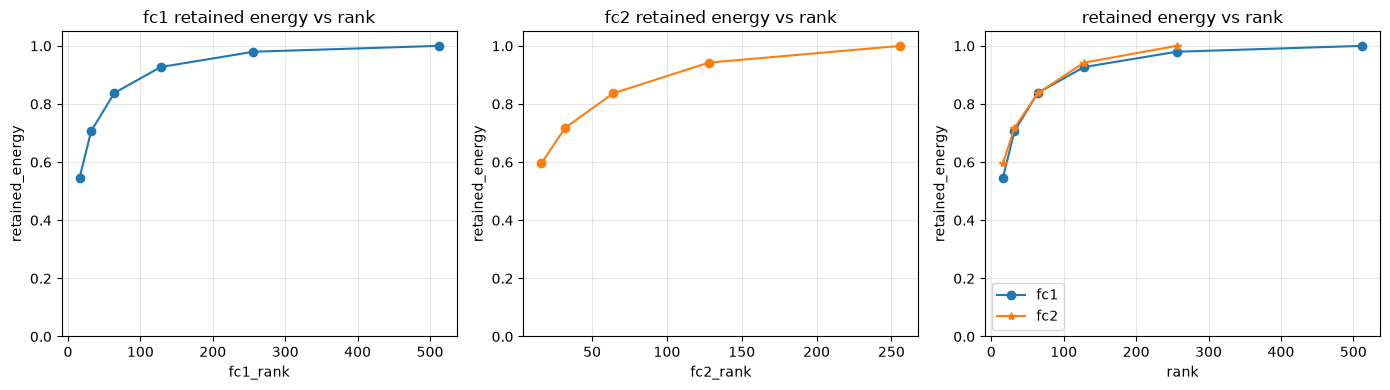

In [31]:
# ============================================================
# retained_energy を rank ごとに図示
# ------------------------------------------------------------
# retained_energy は各層の rank だけで決まるので、
# (fc1_rank, fc2_rank) の組み合わせ表から重複を除いて線にする
# ============================================================
from pathlib import Path
import matplotlib.pyplot as plt

# 全 rank 掃引結果から、層ごとの (rank, energy) を一意にする
df_energy_fc1 = (
    df_results_for_pareto[["fc1_rank", "retained_energy_fc1"]]
    .drop_duplicates("fc1_rank")
    .sort_values("fc1_rank")
)
df_energy_fc2 = (
    df_results_for_pareto[["fc2_rank", "retained_energy_fc2"]]
    .drop_duplicates("fc2_rank")
    .sort_values("fc2_rank")
)

fig_energy, axes_energy = plt.subplots(1, 3, figsize=(14, 4))

# 1) fc1: rank を増やすと残エネルギーがどう上がるか
axes_energy[0].plot(
    df_energy_fc1["fc1_rank"],
    df_energy_fc1["retained_energy_fc1"],
    marker="o",
)
axes_energy[0].set_xlabel("fc1_rank")
axes_energy[0].set_ylabel("retained_energy")
axes_energy[0].set_ylim(0.0, 1.05)
axes_energy[0].set_title("fc1 retained energy vs rank")
axes_energy[0].grid(True, alpha=0.3)

# 2) fc2
axes_energy[1].plot(
    df_energy_fc2["fc2_rank"],
    df_energy_fc2["retained_energy_fc2"],
    marker="o",
    color="C1",
)
axes_energy[1].set_xlabel("fc2_rank")
axes_energy[1].set_ylabel("retained_energy")
axes_energy[1].set_ylim(0.0, 1.05)
axes_energy[1].set_title("fc2 retained energy vs rank")
axes_energy[1].grid(True, alpha=0.3)

# 3) 重ねて比較
axes_energy[2].plot(
    df_energy_fc1["fc1_rank"],
    df_energy_fc1["retained_energy_fc1"],
    marker="o",
    label="fc1",
)
axes_energy[2].plot(
    df_energy_fc2["fc2_rank"],
    df_energy_fc2["retained_energy_fc2"],
    marker="*",
    color="C1",
    label="fc2",
)
axes_energy[2].set_xlabel("rank")
axes_energy[2].set_ylabel("retained_energy")
axes_energy[2].set_ylim(0.0, 1.05)
axes_energy[2].set_title("retained energy vs rank")
axes_energy[2].grid(True, alpha=0.3)
axes_energy[2].legend()

plt.tight_layout()
results_dir.mkdir(parents=True, exist_ok=True)
energy_fig_path = results_dir / "retained_energy_vs_rank.png"
fig_energy.savefig(energy_fig_path, dpi=150, bbox_inches="tight")
print("saved:", energy_fig_path.resolve())
display(df_energy_fc1)
display(df_energy_fc2)
plt.show()


In [32]:
# ============================================================
# 結果の保存
# ------------------------------------------------------------
# CSV（model 列は PyTorch オブジェクトなので保存しない）
#   rank_sweep_results.csv  … 全 rank の掃引結果
#   pareto_frontier.csv     … Pareto 点だけ
#   selected_rank.csv       … knee で選ばれた rank
# あわせて最良モデル重み・図も保存
# ============================================================
results_dir.mkdir(parents=True, exist_ok=True)

# --- CSV ---
# NG（旧）: history.csv 1本だけ、しかもコメントアウトされていた
# history_path = results_dir / "history.csv"
# df_results.to_csv(history_path, index=False)

def _drop_model_col(df):
    """CSV 向けに model 列を除いたコピーを返す"""
    return df.drop(columns=["model"], errors="ignore")

rank_sweep_path = results_dir / "rank_sweep_results.csv"
pareto_path = results_dir / "pareto_frontier.csv"
selected_path = results_dir / "selected_rank.csv"

# 全 rank: Pareto セル先頭で作った表（results 全体）
_drop_model_col(df_results_for_pareto).to_csv(rank_sweep_path, index=False)

# Pareto 点
_drop_model_col(df_pareto_view).to_csv(pareto_path, index=False)

# knee 本体 1 行（前後込みの df_pareto_best ではない）
# NG（旧）: _drop_model_col(df_pareto_best).to_csv(selected_path, index=False)
_drop_model_col(df_pareto_knee).to_csv(selected_path, index=False)

# 参考: knee ±1 も残したい場合
neighbors_path = results_dir / "selected_rank_neighbors.csv"
_drop_model_col(df_pareto_best).to_csv(neighbors_path, index=False)

# --- 3モデルの重み（knee ±1 = df_pareto_best）---
# NG（旧）: 1個だけ保存
# model_path = models_dir / "02_mlp_svd_rank_sweep.pt"
# torch.save(model.state_dict(), model_path)       # baseline を保存してしまっていた
# torch.save(best_model.state_dict(), model_path)  # knee だけ

models_dir.mkdir(parents=True, exist_ok=True)
saved_model_paths = []

for idx, row in df_pareto_best.iterrows():
    # parameters 順での位置からタグを付ける
    if idx < knee_pos:
        tag = "prev"
    elif idx > knee_pos:
        tag = "next"
    else:
        tag = "knee"

    r1 = int(row["fc1_rank"])
    r2 = int(row["fc2_rank"])
    model_path = models_dir / f"r1-{r1}_r2-{r2}_{tag}.pt"  # models_dir が実験名フォルダ
    torch.save(row["model"].state_dict(), model_path)
    saved_model_paths.append(model_path)

# --- 図（Pareto セルで描いた fig があれば）---
figure_path = results_dir / "parameters_vs_validation_loss_normalize.png"
if "fig" in globals():
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")

print(f"saved rank sweep: {rank_sweep_path}")
print(f"saved pareto:     {pareto_path}")
print(f"saved selected:   {selected_path}")
print(f"saved neighbors:  {neighbors_path}")
for path in saved_model_paths:
    print(f"saved model:      {path}")
if "fig" in globals():
    print(f"saved figure:     {figure_path}")


saved rank sweep: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_mlp_svd_rank_selection\rank_sweep_results.csv
saved pareto:     D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_mlp_svd_rank_selection\pareto_frontier.csv
saved selected:   D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_mlp_svd_rank_selection\selected_rank.csv
saved neighbors:  D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_mlp_svd_rank_selection\selected_rank_neighbors.csv
saved model:      D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\02_mlp_svd_rank_selection\r1-32_r2-32_prev.pt
saved model:      D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\02_mlp_svd_rank_selection\r1-64_r2-16_knee.pt
saved model:      D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\02_mlp_svd_rank_selection\r1-64_r2-32_next.pt
saved figure:     D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_mlp_svd_rank_selection\parameters_vs_validation_loss_normalize.png
